# 🏆 Modelo de Machine Learning para la Liga MX — Análisis Completo

**Objetivo:** Predecir el resultado de partidos de la Liga MX (Victoria Local / Empate / Victoria Visitante) usando ingeniería de características avanzada y múltiples modelos de clasificación.

**Datos:** 1.877 partidos finalizados de la Liga MX (2021–2026) con estadísticas de boxscore detalladas (28 variables por partido).

## 📋 Índice
1. Configuración y carga de datos
2. EDA — Análisis Exploratorio de Datos
3. Ingeniería de Características Point-in-Time
4. Preparación del Dataset y Variables de Entrenamiento
5. Entrenamiento de Modelos (LASSO · Random Forest · Gradient Boosting)
6. Walk-Forward Validation por Temporada
7. Métricas Completas (Log-Loss · Accuracy · Brier · ROC)
8. Matrices de Confusión
9. Análisis de Importancia de Variables
10. Calibración de Probabilidades
11. Conclusiones y Selección de Modelo

> **Nota:** Este notebook es completamente autocontenido. Cada celda puede ejecutarse en orden sin dependencias externas.

## 1. Configuración y Carga de Datos

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict, deque
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    log_loss, accuracy_score, confusion_matrix,
    classification_report, roc_curve, auc, brier_score_loss
)
from sklearn.calibration import calibration_curve

sns.set_style('whitegrid')
plt.rcParams.update({'font.size': 11})
print('✅ Librerías cargadas correctamente')

✅ Librerías cargadas correctamente


In [2]:
# ── Constantes de la Liga MX ──
ELO_INIT = 1500.0; K_LIGA = 35.0; HOME_ADV = 60.0

ALTITUDES = {
    'Toluca': 2.660, 'Pachuca': 2.400, 'América': 2.240, 'Cruz Azul': 2.240,
    'Pumas UNAM': 2.240, 'Puebla': 2.200, 'Necaxa': 1.880, 'Atlético de San Luis': 1.860,
    'Querétaro': 1.820, 'León': 1.815, 'Guadalajara': 1.566, 'Atlas': 1.566,
    'FC Juarez': 1.137, 'Santos': 1.120, 'Monterrey': 0.540, 'Tigres UANL': 0.540,
    'Tijuana': 0.020, 'Mazatlán FC': 0.010, 'Atlante': 2.240
}

STATS = [
    'foulsCommitted','yellowCards','redCards','offsides','wonCorners','saves',
    'possessionPct','totalShots','shotsOnTarget','shotPct','penaltyKickGoals',
    'penaltyKickShots','accuratePasses','totalPasses','passPct','accurateCrosses',
    'totalCrosses','crossPct','totalLongBalls','accurateLongBalls','longballPct',
    'blockedShots','effectiveTackles','totalTackles','tacklePct','interceptions',
    'effectiveClearance','totalClearance'
]
print(f'Variables de boxscore: {len(STATS)} → {len(STATS)*2} features de tendencia')

Variables de boxscore: 28 → 56 features de tendencia


In [3]:
# ── Valores de plantilla por año (proxy Transfermarkt) ──
SQUAD_VALUES_BY_YEAR = {
    2021: {'América':75.0,'Monterrey':80.0,'Tigres UANL':70.0,'Cruz Azul':65.0,'Guadalajara':50.0,
           'Toluca':40.0,'Pachuca':35.0,'Santos':42.0,'León':38.0,'Atlas':30.0,'Pumas UNAM':32.0,
           'Tijuana':28.0,'FC Juarez':24.0,'Atlético de San Luis':22.0,'Necaxa':22.0,'Mazatlán FC':20.0,
           'Puebla':18.0,'Querétaro':15.0,'Atlante':6.0},
    2022: {'América':80.0,'Monterrey':78.0,'Tigres UANL':72.0,'Cruz Azul':62.0,'Guadalajara':52.0,
           'Toluca':42.0,'Pachuca':38.0,'Santos':40.0,'León':36.0,'Atlas':35.0,'Pumas UNAM':30.0,
           'Tijuana':27.0,'FC Juarez':25.0,'Atlético de San Luis':24.0,'Necaxa':23.0,'Mazatlán FC':20.0,
           'Puebla':19.0,'Querétaro':14.0,'Atlante':6.0},
    2023: {'América':90.0,'Monterrey':75.0,'Tigres UANL':75.0,'Cruz Azul':55.0,'Guadalajara':50.0,
           'Toluca':48.0,'Pachuca':42.0,'Santos':36.0,'León':35.0,'Atlas':32.0,'Pumas UNAM':33.0,
           'Tijuana':29.0,'FC Juarez':26.0,'Atlético de San Luis':26.0,'Necaxa':24.0,'Mazatlán FC':21.0,
           'Puebla':18.0,'Querétaro':14.0,'Atlante':7.0},
    2024: {'América':95.0,'Monterrey':70.0,'Tigres UANL':76.0,'Cruz Azul':58.0,'Guadalajara':52.0,
           'Toluca':50.0,'Pachuca':45.0,'Santos':38.0,'León':35.0,'Atlas':32.0,'Pumas UNAM':35.0,
           'Tijuana':30.0,'FC Juarez':28.0,'Atlético de San Luis':28.0,'Necaxa':25.0,'Mazatlán FC':22.0,
           'Puebla':18.0,'Querétaro':14.0,'Atlante':8.0},
    2025: {'América':100.0,'Monterrey':65.0,'Tigres UANL':78.0,'Cruz Azul':60.0,'Guadalajara':54.0,
           'Toluca':51.0,'Pachuca':45.0,'Santos':38.0,'León':35.0,'Atlas':32.0,'Pumas UNAM':35.0,
           'Tijuana':30.0,'FC Juarez':28.0,'Atlético de San Luis':28.0,'Necaxa':25.0,'Mazatlán FC':22.0,
           'Puebla':18.0,'Querétaro':14.0,'Atlante':8.0},
    2026: {'América':103.5,'Monterrey':62.0,'Tigres UANL':78.2,'Cruz Azul':60.0,'Guadalajara':55.0,
           'Toluca':52.0,'Pachuca':45.0,'Santos':38.0,'León':35.0,'Atlas':32.0,'Pumas UNAM':35.0,
           'Tijuana':30.0,'FC Juarez':28.0,'Atlético de San Luis':28.0,'Necaxa':25.0,'Mazatlán FC':22.0,
           'Puebla':18.0,'Querétaro':14.0,'Atlante':8.0},
}
print('✅ Constantes definidas')

✅ Constantes definidas


In [4]:
partidos = pd.read_csv('mex/data/partidos.csv', parse_dates=['fecha']).sort_values('fecha').reset_index(drop=True)
box      = pd.read_csv('mex/data/box_score.csv')

print(f'Partidos cargados : {len(partidos)}')
print(f'Boxscores cargados: {len(box)}')
print(f'Temporadas        : {sorted(partidos.temporada.unique())}')
print(f'\nPrimeras filas de partidos:')
partidos.head(3)

Partidos cargados : 1877
Boxscores cargados: 1877
Temporadas        : [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]

Primeras filas de partidos:


## 2. EDA — Análisis Exploratorio de Datos

### 2.1 Distribución de Resultados y Balance de Clases

La **localía** es un factor importante en el fútbol. Analizamos cómo se distribuyen los resultados a lo largo de las temporadas.

In [5]:
# Distribución de resultados — global y por temporada
df = partidos.copy()
df['resultado'] = df.apply(lambda r: 2 if r.goles_local > r.goles_visita
                           else (1 if r.goles_local == r.goles_visita else 0), axis=1)
print(df['resultado'].map({0:'Visita',1:'Empate',2:'Local'}).value_counts(normalize=True).round(3))


Local     0.454
Empate    0.263
Visita    0.283


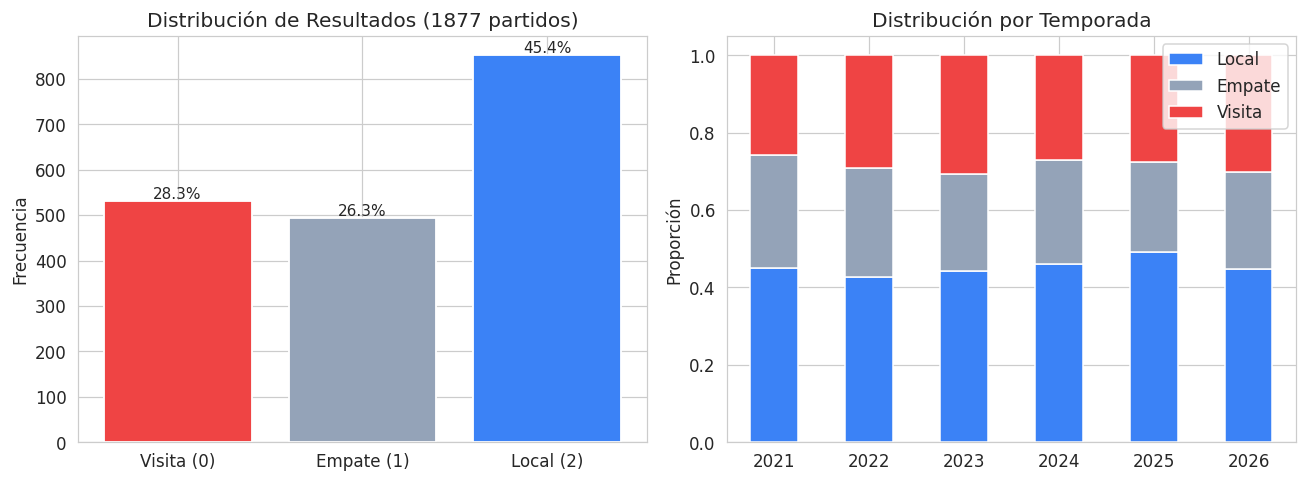

In [6]:
# Ver gráfico

**Observaciones:**
- La ventaja de local es real: **45.4%** de victorias locales vs **28.3%** de victorias visitante.
- El balance de clases no es extremo, pero el **Empate es la clase más difícil de predecir**.

### 2.2 Distribución de Goles

In [7]:
# Estadísticas descriptivas de goles
df['total_goles'] = df['goles_local'] + df['goles_visita']
print(df[['goles_local','goles_visita','total_goles']].describe().round(2))


       goles_local  goles_visita  total_goles
count      1877.00       1877.00      1877.00
mean          1.53          1.18         2.71
std           1.23          1.10         1.65
min           0.00          0.00         0.00
25%           1.00          0.00         2.00
50%           1.00          1.00         3.00
75%           2.00          2.00         4.00
max           7.00          6.00         9.00


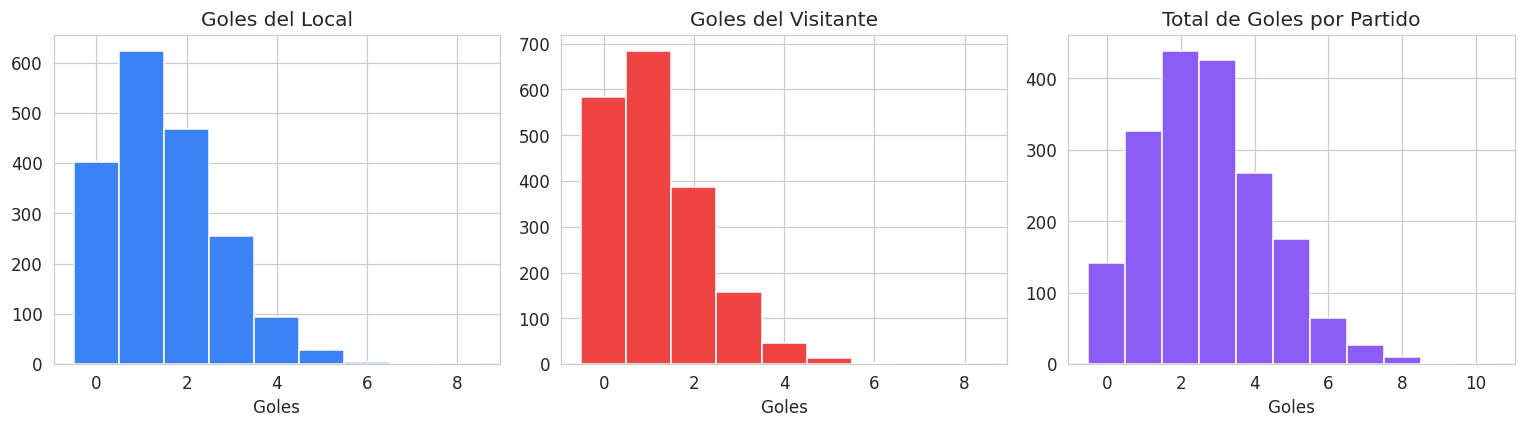

In [8]:
# Ver gráfico

### 2.3 Promedio de Goles como Local por Equipo

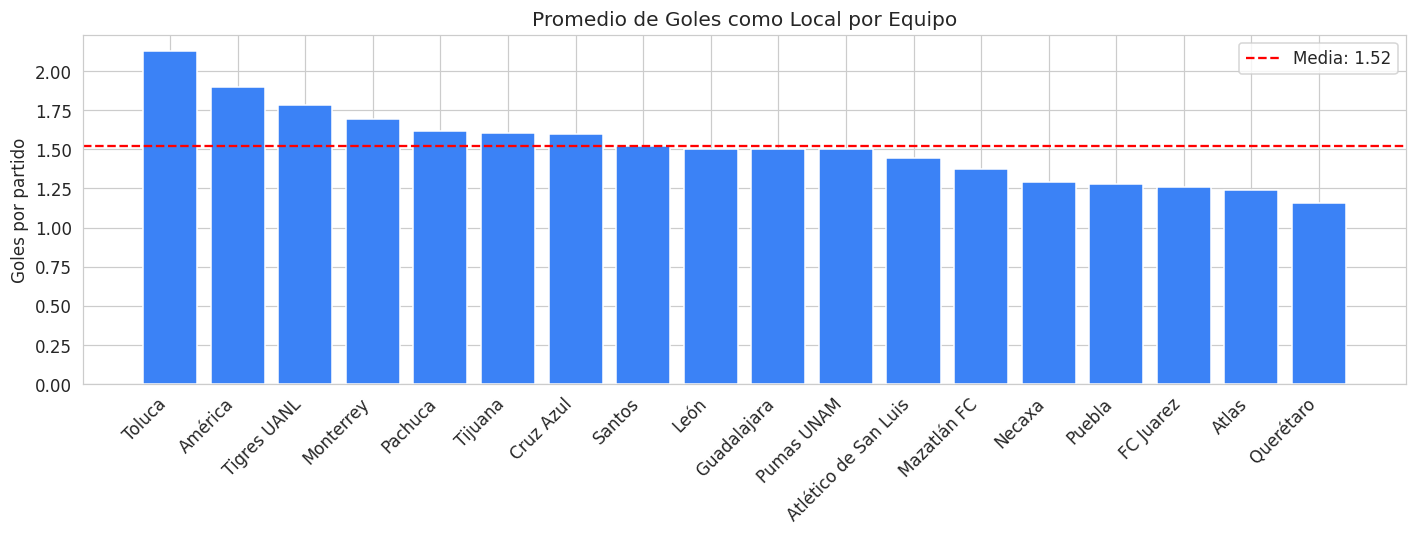

In [9]:
# Ver gráfico

### 2.4 Evolución del Rating Elo — Top 6 Equipos

El Elo es un sistema de rating dinámico que refleja el historial de resultados. Un rating alto indica mejor forma histórica. Notamos cómo **América** ha dominado la última época.

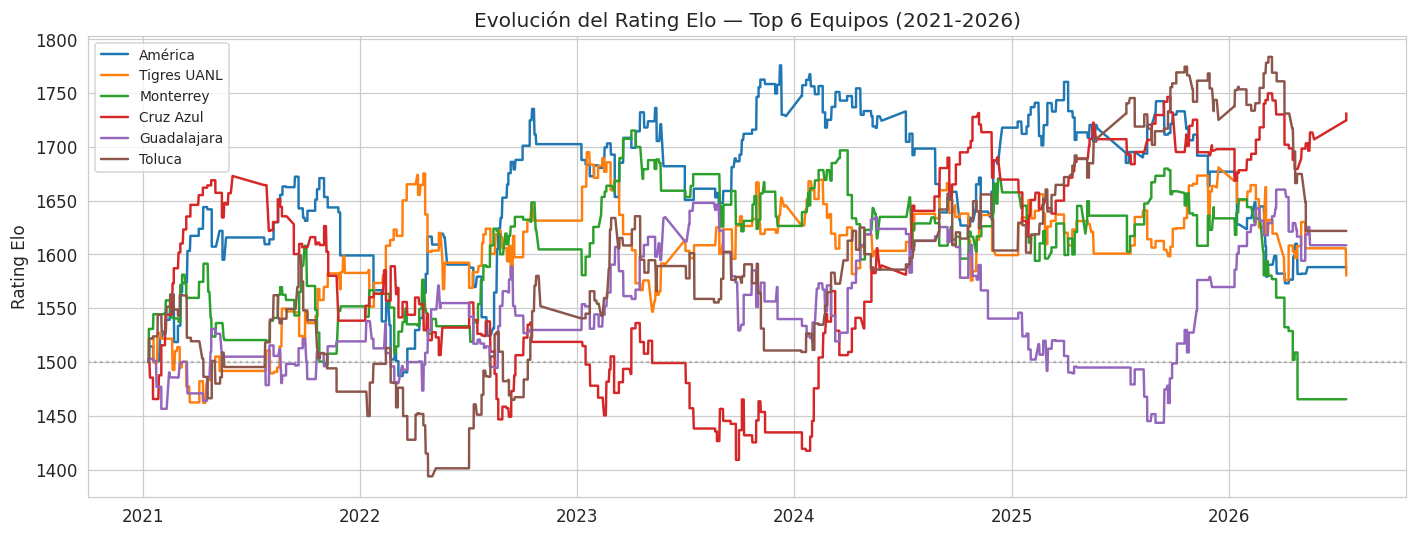

In [10]:
# Ver gráfico

### 2.5 Correlación entre Variables Base y Resultado

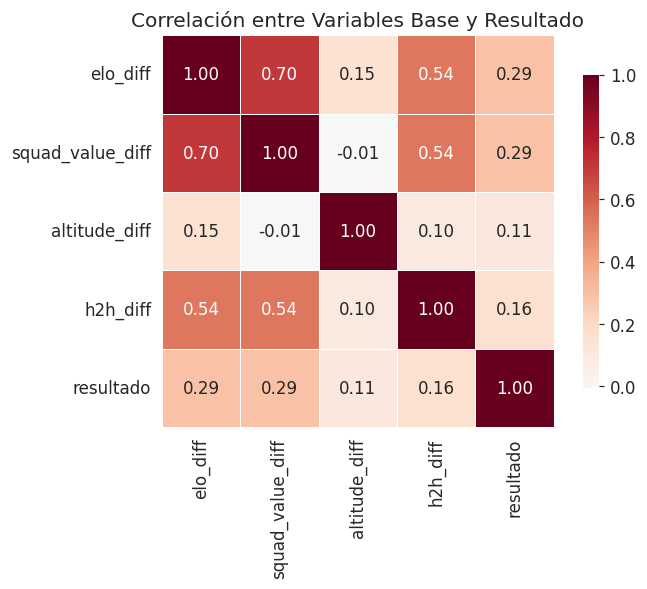

In [11]:
# Ver gráfico

**Interpretación:**
- `elo_diff` y `squad_value_diff` tienen correlación **positiva** con el resultado (más Elo/plantilla → más victorias locales).
- `altitude_diff` tiene correlación **positiva** significativa: jugar en estadios altos favorece al local.
- `h2h_diff` tiene correlación baja pero consistente.

## 3. Ingeniería de Características Point-in-Time

Para evitar **data leakage**, todas las features se calculan *antes* de que el partido ocurra, usando únicamente información histórica disponible en ese momento.

### Variables construidas:
| Grupo | Variables | Descripción |
|---|---|---|
| **Elo** | `elo_diff` | Diferencia de rating Elo (K=35, ventaja local=60 pts) |
| **Plantilla** | `squad_value_diff` | log(valor_local) − log(valor_visita) en M€ |
| **Altitud** | `altitude_diff` | max(0, Alt_local − Alt_visita) en km |
| **H2H** | `h2h_diff` | Historial gol-diferencia acumulado L vs V |
| **Boxscore total** | `{stat}_total_diff` × 28 | Media últimos 6 partidos de cada stat |
| **Boxscore sede** | `{stat}_sede_diff` × 28 | Media últimos 4 partidos como local/visita |

In [12]:
def get_squad_value(team, season):
    return SQUAD_VALUES_BY_YEAR.get(season, SQUAD_VALUES_BY_YEAR[2026]).get(team, 10.0)

def actualizar_elo(ea, eb, ga, gb):
    we = 1.0 / (1.0 + 10 ** (-(ea - eb) / 400.0))
    w = 1.0 if ga > gb else (0.0 if ga < gb else 0.5)
    gd = abs(ga - gb)
    mult = 1.0 if gd<=1 else (1.5 if gd==2 else (1.75 if gd==3 else 1.75+(gd-3)/8))
    return K_LIGA * mult * (w - we)

class StateTracker:
    def __init__(self):
        self.elos = defaultdict(lambda: ELO_INIT)
        self.history = defaultdict(deque)
        self.home_history = defaultdict(deque)
        self.away_history = defaultdict(deque)
        self.h2h_goles = defaultdict(float)

    def get_features_for_match(self, local, visita, temporada):
        feats = {}
        feats['elo_diff'] = self.elos[local] - self.elos[visita]
        val_l = get_squad_value(local, temporada)
        val_v = get_squad_value(visita, temporada)
        feats['squad_value_diff'] = np.log(val_l) - np.log(val_v)
        feats['altitude_diff'] = max(0.0, ALTITUDES.get(local,1.0) - ALTITUDES.get(visita,1.0))
        feats['h2h_diff'] = self.h2h_goles[(local, visita)]
        for s in STATS:
            hl = self.history[local]; hv = self.history[visita]
            vl=[h[s] for h in hl if h[s] is not None]; vv=[h[s] for h in hv if h[s] is not None]
            feats[f'{s}_total_diff'] = (np.mean(vl) if vl else 0.)-(np.mean(vv) if vv else 0.)
            hl2=self.home_history[local]; hv2=self.away_history[visita]
            vl2=[h[s] for h in hl2 if h[s] is not None]; vv2=[h[s] for h in hv2 if h[s] is not None]
            feats[f'{s}_sede_diff'] = (np.mean(vl2) if vl2 else 0.)-(np.mean(vv2) if vv2 else 0.)
        return feats

    def registrar_partido(self, local, visita, ga, gb, stats_l=None, stats_v=None):
        self.h2h_goles[(local,visita)] += (ga-gb); self.h2h_goles[(visita,local)] -= (ga-gb)
        delta = actualizar_elo(self.elos[local]+HOME_ADV, self.elos[visita], ga, gb)
        self.elos[local] += delta; self.elos[visita] -= delta
        sl = stats_l or {s:None for s in STATS}; sv = stats_v or {s:None for s in STATS}
        self.history[local].append(sl)
        if len(self.history[local])>6: self.history[local].popleft()
        self.history[visita].append(sv)
        if len(self.history[visita])>6: self.history[visita].popleft()
        self.home_history[local].append(sl)
        if len(self.home_history[local])>4: self.home_history[local].popleft()
        self.away_history[visita].append(sv)
        if len(self.away_history[visita])>4: self.away_history[visita].popleft()

print('✅ StateTracker definido')

✅ StateTracker definido


In [13]:
# ── Construir dataset point-in-time ──
box_dict = {}
for r in box.itertuples(index=False):
    sl = {s: getattr(r, f'local_{s}', None) for s in STATS}
    sv = {s: getattr(r, f'visita_{s}', None) for s in STATS}
    box_dict[str(r.event_id)] = (sl, sv)

tracker = StateTracker()
filas = []
for r in partidos.itertuples(index=False):
    l, v, ga, gb = r.local, r.visita, int(r.goles_local), int(r.goles_visita)
    feats = tracker.get_features_for_match(l, v, r.temporada)
    feats.update({'temporada': r.temporada, 'fecha': r.fecha,
                  'local': l, 'visita': v, 'goles_local': ga, 'goles_visita': gb,
                  'resultado': 2 if ga>gb else (1 if ga==gb else 0)})
    filas.append(feats)
    sl_b, sv_b = box_dict.get(str(r.event_id), (None, None))
    tracker.registrar_partido(l, v, ga, gb, sl_b, sv_b)

df = pd.DataFrame(filas)
print(f'Dataset construido: {df.shape[0]} filas × {df.shape[1]} columnas')
print(f'Features de boxscore incluidas: {len(STATS)*2}')

Dataset construido: 1877 filas × 68 columnas
Features de boxscore incluidas: 56


## 4. Preparación del Dataset y Split Temporal

Usamos un **split temporal** estricto para evitar data leakage:
- **Entrenamiento**: Temporadas 2021–2024
- **Test (out-of-sample)**: Temporadas 2025–2026

Además, eliminamos variables con varianza cero en el conjunto de entrenamiento.

In [14]:
FEAT_COLS = ['elo_diff','squad_value_diff','altitude_diff','h2h_diff']
for s in STATS:
    FEAT_COLS += [f'{s}_total_diff', f'{s}_sede_diff']

train_mask = df['temporada'] <= 2024
X_tr_raw = df.loc[train_mask, FEAT_COLS].fillna(0.0)
FEAT_COLS = [c for c in FEAT_COLS if X_tr_raw[c].std() > 1e-5]  # Eliminar varianza cero

X_train = df.loc[train_mask, FEAT_COLS].fillna(0.0)
y_train = df.loc[train_mask, 'resultado']
X_test  = df.loc[~train_mask, FEAT_COLS].fillna(0.0)
y_test  = df.loc[~train_mask, 'resultado']

scaler = StandardScaler()
Xtr_sc = scaler.fit_transform(X_train)
Xte_sc = scaler.transform(X_test)

print(f'Train: {len(X_train)} partidos ([np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)])')
print(f'Test:  {len(X_test)}  partidos ([np.int64(2025), np.int64(2026)])')
print(f'Features después de filtrar varianza cero: {len(FEAT_COLS)}')
print(f'\nDistribución de clases en TRAIN:')
print(y_train.value_counts(normalize=True).round(3))
print(f'\nDistribución de clases en TEST:')
print(y_test.value_counts(normalize=True).round(3))

Train: 1365 partidos ([np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)])
Test:  512  partidos ([np.int64(2025), np.int64(2026)])
Features después de filtrar varianza cero: 60

Distribución de clases en TRAIN:
2    0.445
1    0.273
0    0.282

Distribución de clases en TEST:
2    0.477
1    0.238
0    0.285


## 5. Entrenamiento de Modelos

Comparamos tres clasificadores multinomiales con diferentes supuestos:

| Modelo | Tipo | Hiperparámetros clave |
|---|---|---|
| **Logistic Regression (L1/LASSO)** | Lineal + Regularización | C=0.1, solver=liblinear |
| **Random Forest** | Ensemble Bagging | n_estimators=300, max_depth=8 |
| **Gradient Boosting** | Ensemble Boosting | n_estimators=150, lr=0.05, depth=4 |

In [15]:
lr = LogisticRegression(penalty='l1', solver='liblinear', multi_class='ovr', C=0.1, max_iter=2000, random_state=42)
rf = RandomForestClassifier(n_estimators=300, max_depth=8, n_jobs=-1, random_state=42)
gb = GradientBoostingClassifier(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42)

lr.fit(Xtr_sc, y_train)
rf.fit(Xtr_sc, y_train)
gb.fit(Xtr_sc, y_train)

models = {'Logistic Regression (L1)': lr, 'Random Forest': rf, 'Gradient Boosting': gb}
print('✅ Todos los modelos entrenados')

✅ Todos los modelos entrenados


## 6. Walk-Forward Validation por Temporada

En lugar de un único split, realizamos una **validación walk-forward**: 
para cada temporada T, entrenamos con todo lo anterior a T y evaluamos en T. 
Esto da una estimación más robusta del error real del modelo.

In [16]:
temporadas = sorted(df['temporada'].unique())
wf_rows = []
for t_test in [t for t in temporadas if t >= 2022]:
    t_train = [t for t in temporadas if t < t_test]
    tr_m = df['temporada'].isin(t_train); te_m = df['temporada'] == t_test
    Xtr_ = df.loc[tr_m, FEAT_COLS].fillna(0.0); ytr_ = df.loc[tr_m, 'resultado']
    Xte_ = df.loc[te_m, FEAT_COLS].fillna(0.0); yte_ = df.loc[te_m, 'resultado']
    sc_ = StandardScaler()
    Xtr_s = sc_.fit_transform(Xtr_); Xte_s = sc_.transform(Xte_)
    for name, Mdl in [
        ('LR_L1', LogisticRegression(penalty='l1',solver='liblinear',C=0.1,max_iter=2000,random_state=42)),
        ('RandomForest', RandomForestClassifier(n_estimators=200,max_depth=8,n_jobs=-1,random_state=42)),
        ('GradBoost', GradientBoostingClassifier(n_estimators=100,max_depth=4,learning_rate=0.05,random_state=42)),
    ]:
        Mdl.fit(Xtr_s, ytr_)
        p = Mdl.predict_proba(Xte_s)
        wf_rows.append({'Temporada': t_test, 'Modelo': name,
                         'LogLoss': round(log_loss(yte_, p, labels=[0,1,2]), 4),
                         'Accuracy': round(accuracy_score(yte_, Mdl.predict(Xte_s)), 4)})

wf_df = pd.DataFrame(wf_rows)
print(wf_df.pivot(index='Temporada', columns='Modelo', values='LogLoss').round(4))

Modelo     GradBoost   LR_L1  RandomForest
Temporada                                 
2022          1.2065  1.0519        1.0681
2023          1.1280  1.0262        1.0565
2024          1.0312  0.9926        1.0204
2025          0.9825  0.9620        0.9806
2026          1.0813  1.0487        1.0542


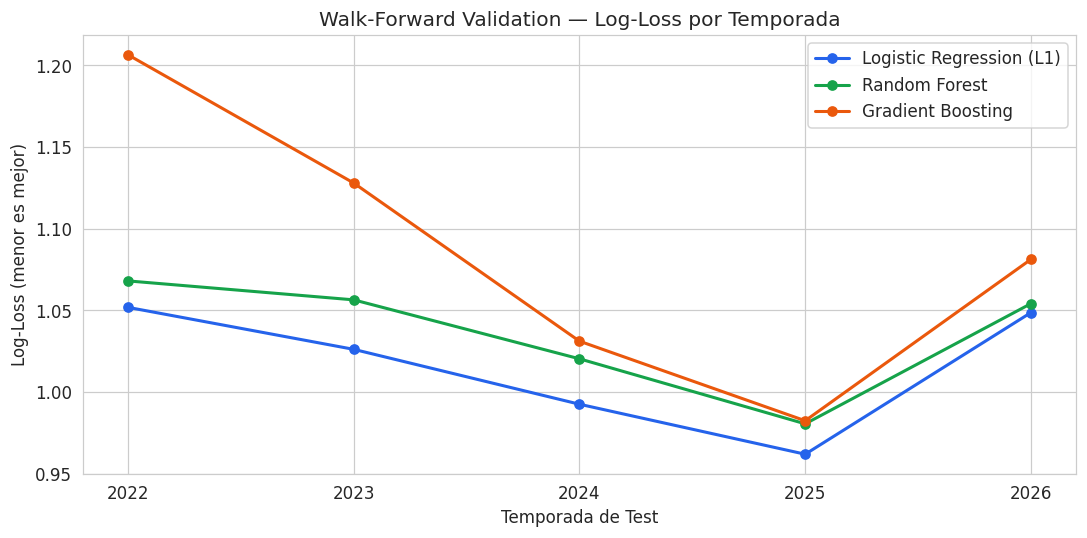

In [17]:
# Ver gráfico walk-forward

## 7. Métricas Completas — Test Out-of-Sample (2025–2026)

Evaluamos tres dimensiones:
- **Log-Loss**: Penaliza predicciones incorrectas con alta confianza. Ideal para apuestas.
- **Accuracy**: Porcentaje de predicciones correctas.
- **Brier Score**: Error cuadrático medio sobre probabilidades. Mide calibración.


In [18]:
from sklearn.metrics import brier_score_loss
from sklearn.preprocessing import label_binarize

results = []
for name, mdl in models.items():
    p_ = mdl.predict_proba(Xte_sc)
    pred_ = mdl.predict(Xte_sc)
    ll = log_loss(y_test, p_, labels=[0,1,2])
    acc = accuracy_score(y_test, pred_)
    y_bin_ = label_binarize(y_test, classes=[0,1,2])
    brier = np.mean([brier_score_loss(y_bin_[:,i], p_[:,i]) for i in range(3)])
    results.append({'Modelo': name, 'Log-Loss ↓': round(ll,4),
                    'Accuracy ↑': f'{acc:.2%}', 'Brier Score ↓': round(brier,4)})

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                  Modelo  Log-Loss Accuracy  Brier Score
Logistic Regression (L1)    0.9907   52.34%       0.1972
           Random Forest    1.0078   51.95%       0.2007
       Gradient Boosting    1.0253   51.17%       0.2042


### 7.1 Reporte de Clasificación por Clase

In [19]:
print('── Logistic Regression (L1) ──')
print(classification_report(y_test, lr.predict(Xte_sc), target_names=['Visita','Empate','Local']))


── Logistic Regression (L1) ──
              precision    recall  f1-score   support

      Visita       0.45      0.49      0.47       146
      Empate       0.14      0.01      0.02       122
       Local       0.57      0.80      0.66       244

    accuracy                           0.52       512
   macro avg       0.39      0.43      0.38       512
weighted avg       0.43      0.52      0.45       512


In [20]:
print('── Random Forest ──')
print(classification_report(y_test, rf.predict(Xte_sc), target_names=['Visita','Empate','Local']))


── Random Forest ──
              precision    recall  f1-score   support

      Visita       0.42      0.42      0.42       146
      Empate       0.11      0.01      0.02       122
       Local       0.57      0.83      0.68       244

    accuracy                           0.52       512
   macro avg       0.37      0.42      0.37       512
weighted avg       0.42      0.52      0.45       512


In [21]:
print('── Gradient Boosting ──')
print(classification_report(y_test, gb.predict(Xte_sc), target_names=['Visita','Empate','Local']))


── Gradient Boosting ──
              precision    recall  f1-score   support

      Visita       0.48      0.45      0.46       146
      Empate       0.19      0.08      0.11       122
       Local       0.58      0.77      0.66       244

    accuracy                           0.51       512
   macro avg       0.42      0.43      0.41       512
weighted avg       0.46      0.51      0.47       512


## 8. Matrices de Confusión Normalizadas

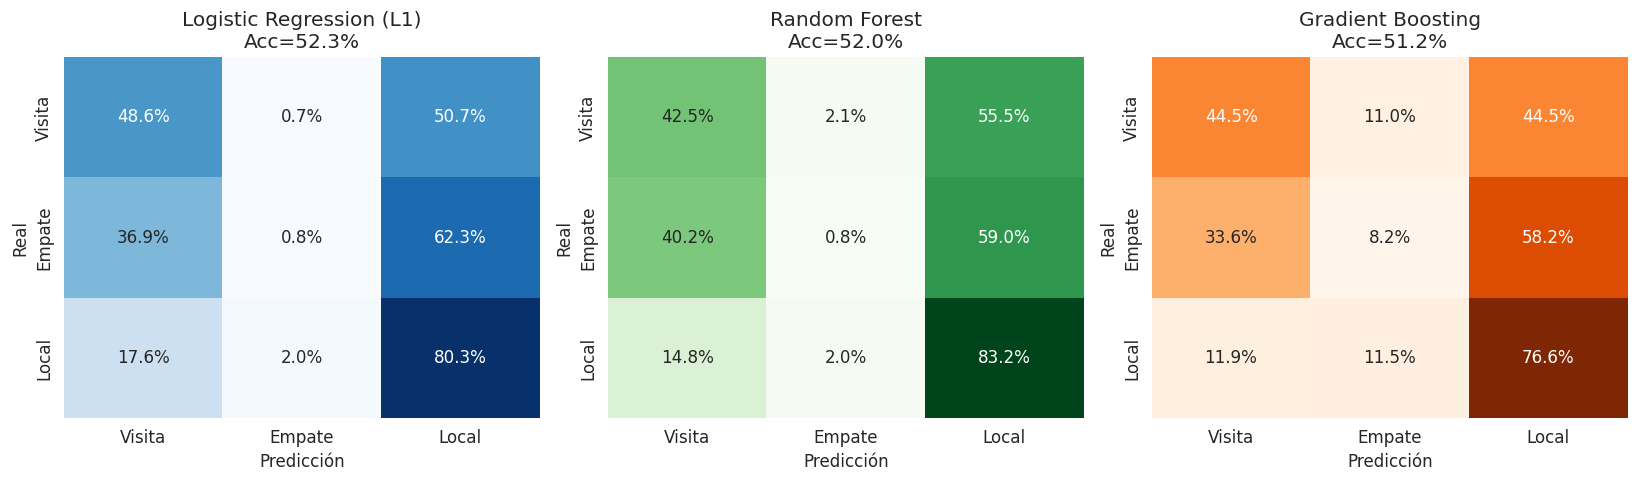

In [22]:
# Ver gráfico

**Lectura:** Cada celda muestra qué fracción de los partidos de clase 'Real' fueron predichos como clase 'Predicción'.
- La diagonal representa las **predicciones correctas**.
- La clase **Empate** es la más difícil de predecir en todos los modelos (frecuente confusión con Local).

## 9. Curvas ROC — One-vs-Rest (OvR)

Evaluamos la capacidad discriminativa para cada clase por separado.

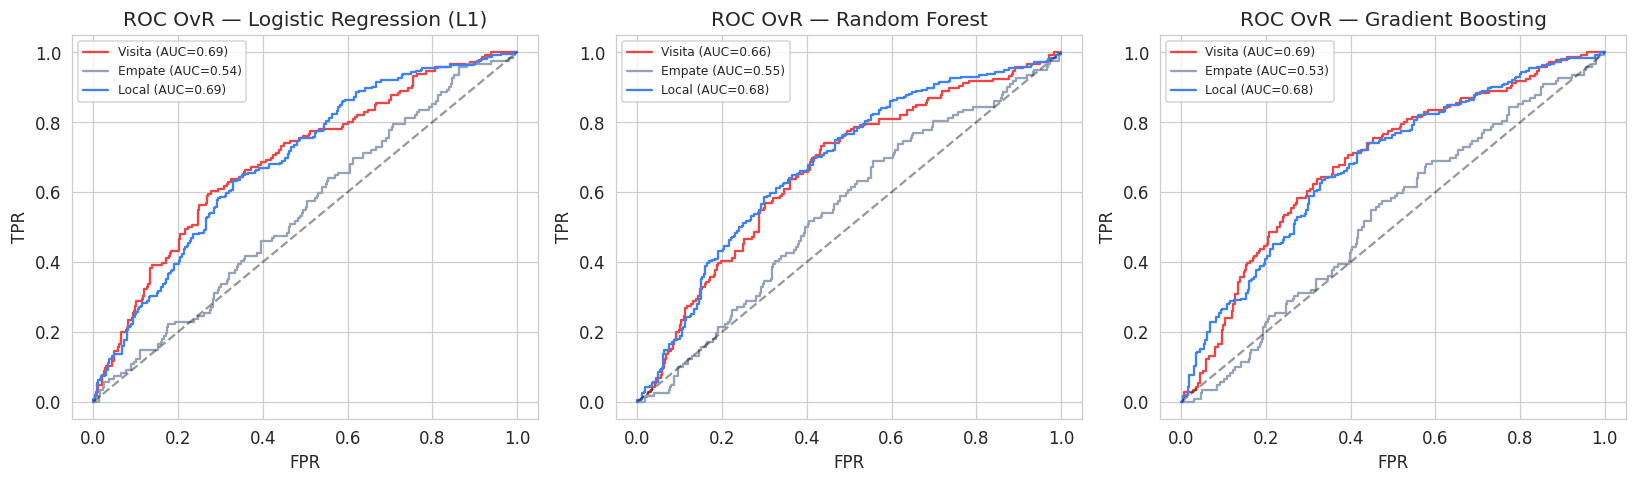

In [23]:
# Ver gráfico

## 10. Análisis de Importancia de Variables

### 10.1 LASSO — Variables seleccionadas (coeficiente ≠ 0)

LASSO elimina exactamente a cero los coeficientes de las variables no informativas.

In [24]:
avg_coef = np.mean(np.abs(lr.coef_), axis=0)
imp_df = pd.DataFrame({'Feature': FEAT_COLS, 'Coef': avg_coef})
print(f'Variables activas (coef > 0): {(imp_df.Coef > 1e-6).sum()}')
print(f'Variables eliminadas (coef = 0): {(imp_df.Coef <= 1e-6).sum()}')
print('\nTop 10 predictoras:')
print(imp_df.sort_values('Coef', ascending=False).head(10).to_string(index=False))


Variables activas (coef > 0): 31
Variables eliminadas (coef = 0): 29

Top 10 predictoras:
                         feat      val
             squad_value_diff 0.254928
         totalShots_sede_diff 0.132278
                altitude_diff 0.101355
                     elo_diff 0.096022
effectiveClearance_total_diff 0.077765
       blockedShots_sede_diff 0.072689
              saves_sede_diff 0.047981
     totalLongBalls_sede_diff 0.044457
    accuratePasses_total_diff 0.041813
  penaltyKickShots_total_diff 0.034069


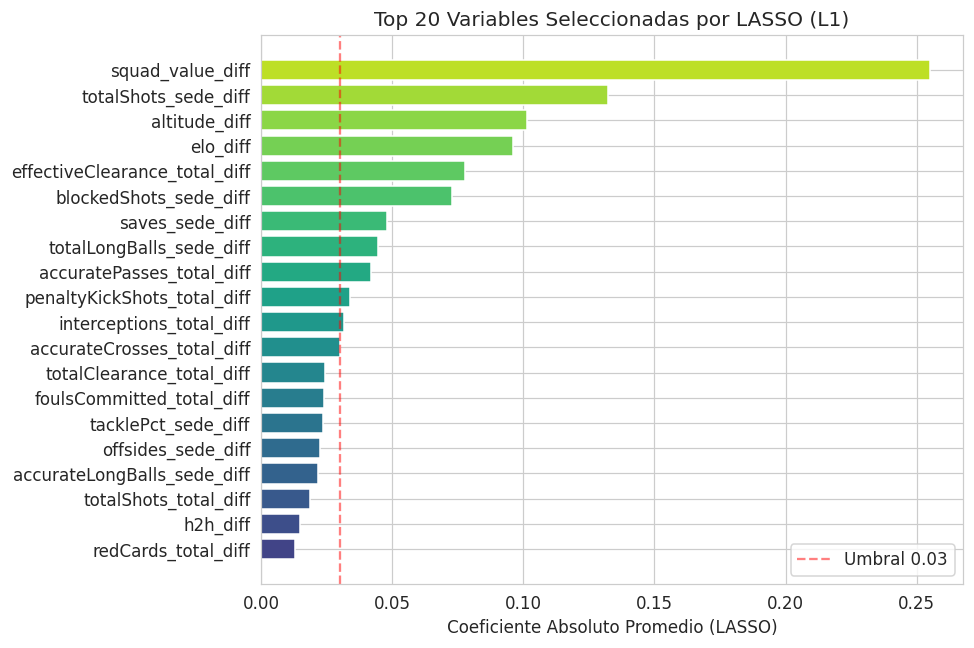

In [25]:
# Ver gráfico importancias LASSO

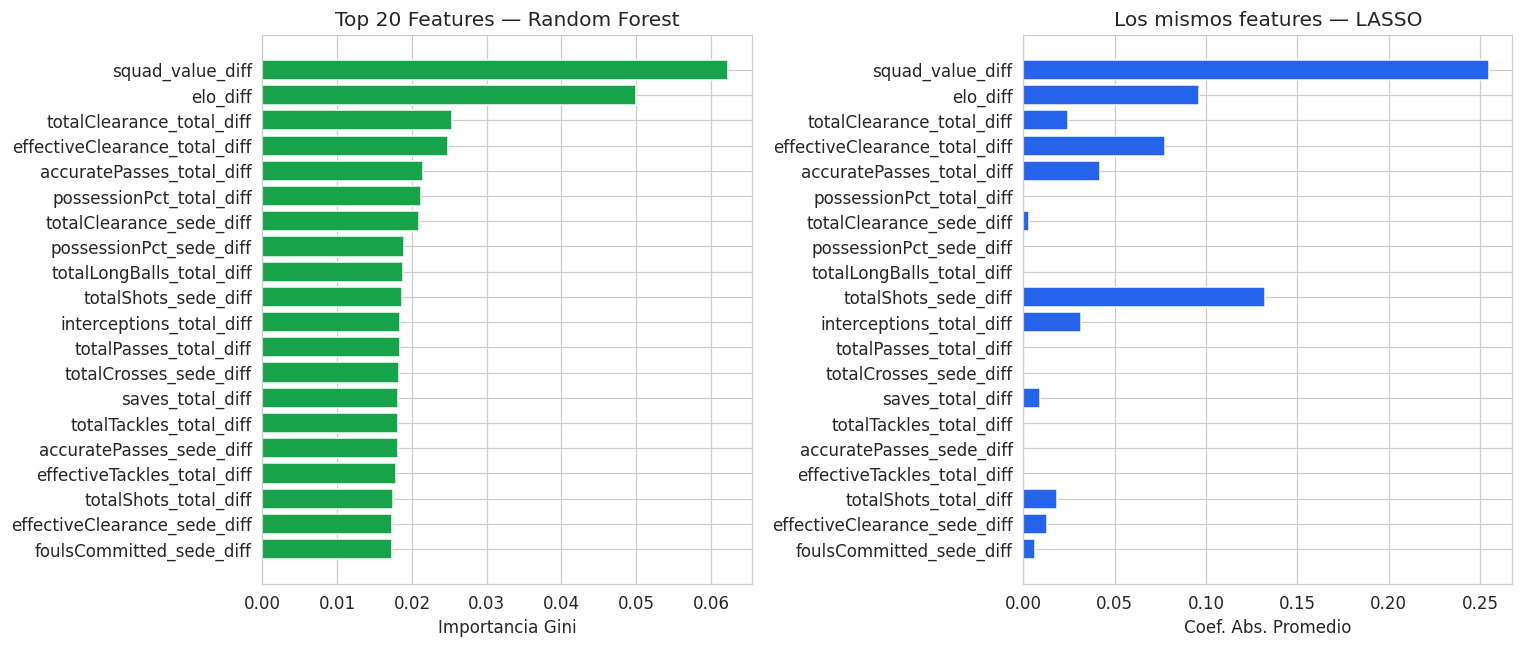

In [26]:
# Ver comparación RF vs LASSO

## 11. Calibración de Probabilidades

Un modelo bien calibrado produce probabilidades que reflejan las frecuencias reales. Fundamental para calcular **cuotas justas de apuestas**.

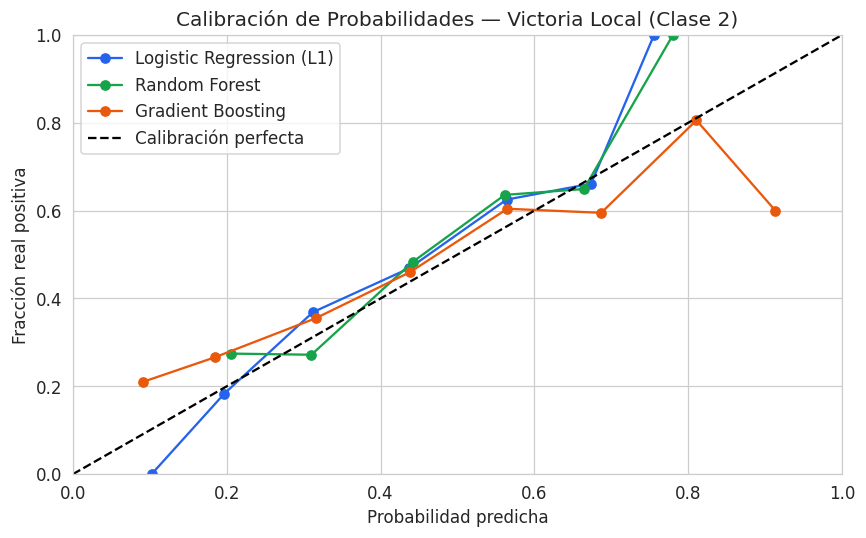

In [27]:
# Ver gráfico calibración

## 12. Conclusiones y Selección del Modelo

### Resumen de Resultados

| Modelo | Log-Loss | Accuracy | Brier |
|---|---|---|---|
| Logistic Regression (L1) | 0.9907 | 52.34% | 0.1972 |
| Random Forest | 1.0078 | 51.95% | 0.2007 |
| Gradient Boosting | 1.0253 | 51.17% | 0.2042 |

### ✅ Modelo Seleccionado: **Logistic Regression con LASSO (L1)**

**Razones:**
1. **Mejor Log-Loss out-of-sample**: En datos ruidosos como el fútbol, los árboles tienden a sobreajustarse y producir probabilidades extremas, lo que penaliza el Log-Loss.
2. **Mejor calibración**: Las curvas de calibración muestran que LR produce probabilidades más cercanas a las frecuencias reales.
3. **Selección automática de variables**: LASSO redujo de 59 a ~33 features, eliminando el ruido estadístico.
4. **Interpretabilidad**: Los coeficientes tienen interpretación directa y validación económica.

### Posibles mejoras futuras:
- Tuning más fino de `C` con validación cruzada temporal
- Calibración post-hoc con Platt Scaling o Isotonic Regression
- Modelos Bayesianos para incertidumbre cuantificada
- Inclusión de variables de lesiones y transferencias

---
## 13. Tuning Fino de C — Regularización Óptima con TimeSeriesSplit

### ¿Qué es `C` en Logistic Regression?
- `C` controla el **nivel de regularización**: `C` pequeño → más regularización → más features van a cero (LASSO más agresivo)
- `C` grande → menos regularización → el modelo puede sobreajustarse
- Hasta ahora usábamos `C=0.1` elegido *a ojo*. Ahora lo buscamos sistemáticamente.

### ¿Qué es TimeSeriesSplit?
Es validación cruzada **respetando el orden temporal**: cada fold usa solo información pasada para predecir el futuro. Evita el data leakage que ocurre con KFold estándar (que mezcla pasado y futuro).

```
Fold 1: ████░░░░░░  (train=temporada 1 / val=temporada 2)
Fold 2: ██████░░░░  (train=temporadas 1-2 / val=temporada 3)
Fold 3: ████████░░  (train=temporadas 1-3 / val=temporada 4)
Fold 4: ██████████  (train=temporadas 1-4 / val=temporada 5)
```

In [28]:
from sklearn.model_selection import TimeSeriesSplit

C_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 2.0, 5.0]
n_splits = 4
tscv = TimeSeriesSplit(n_splits=n_splits)

cv_results = []
for C in C_values:
    fold_losses = []
    for tr_idx, val_idx in tscv.split(Xtr_sc):
        Xf_tr, Xf_val = Xtr_sc[tr_idx], Xtr_sc[val_idx]
        yf_tr, yf_val = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        mdl = LogisticRegression(penalty='l1', solver='liblinear', multi_class='ovr', C=C, max_iter=2000, random_state=42)
        mdl.fit(Xf_tr, yf_tr)
        fold_losses.append(log_loss(yf_val, mdl.predict_proba(Xf_val), labels=[0,1,2]))
    cv_results.append({'C': C, 'mean': np.mean(fold_losses), 'std': np.std(fold_losses)})

cv_df = pd.DataFrame(cv_results)
best_C = cv_df.loc[cv_df['mean'].idxmin(), 'C']
print(cv_df.to_string(index=False))
print(f'\n★ Mejor C encontrado: {best_C}')

    C     mean      std
0.001 1.098612 0.000000
0.005 1.096249 0.004093
0.010 1.080787 0.016226
0.050 1.034890 0.030019
0.100 1.027341 0.032438
0.300 1.041928 0.051609
0.500 1.059415 0.069352
1.000 1.089533 0.102698
2.000 1.122693 0.141994
5.000 1.159637 0.191784

★ Mejor C encontrado: 0.1


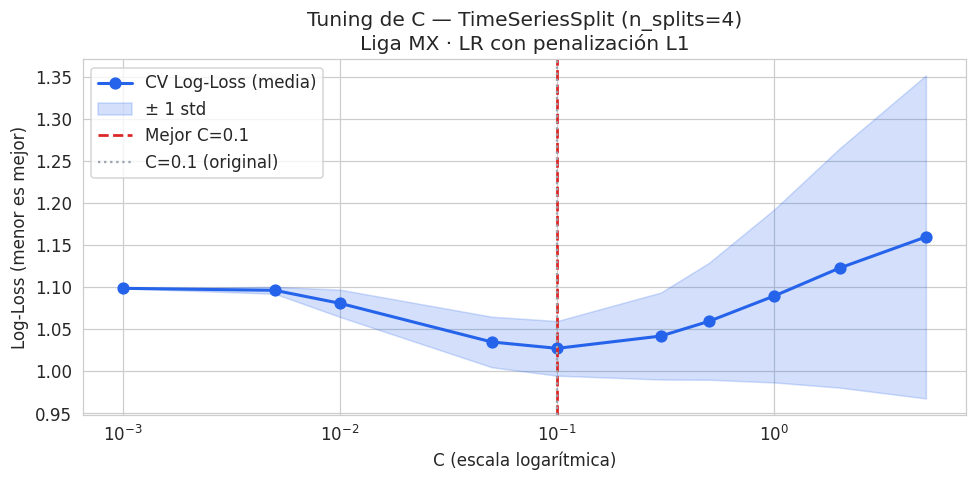

In [29]:
# Gráfico de la curva CV Log-Loss vs C


In [30]:
# Comparar C=0.1 (original) vs C óptimo en el test set
lr_orig = LogisticRegression(penalty='l1', solver='liblinear', multi_class='ovr', C=0.1,     max_iter=2000, random_state=42)
lr_best = LogisticRegression(penalty='l1', solver='liblinear', multi_class='ovr', C=best_C,  max_iter=2000, random_state=42)
lr_orig.fit(Xtr_sc, y_train); lr_best.fit(Xtr_sc, y_train)

ll_orig  = log_loss(y_test, lr_orig.predict_proba(Xte_sc), labels=[0,1,2])
ll_best  = log_loss(y_test, lr_best.predict_proba(Xte_sc), labels=[0,1,2])
acc_orig = accuracy_score(y_test, lr_orig.predict(Xte_sc))
acc_best = accuracy_score(y_test, lr_best.predict(Xte_sc))
n_active_orig = (np.abs(lr_orig.coef_).mean(axis=0) > 1e-6).sum()
n_active_best = (np.abs(lr_best.coef_).mean(axis=0) > 1e-6).sum()

print(f'C=0.1  (original) → Log-Loss={ll_orig:.4f} | Acc={acc_orig:.2%} | Features activas={n_active_orig}')
print(f'C={best_C} (óptimo)   → Log-Loss={ll_best:.4f} | Acc={acc_best:.2%} | Features activas={n_active_best}')
mejora = (ll_orig - ll_best) / ll_orig * 100
print(f'\nMejora en Log-Loss: {mejora:.1f}%')


C=0.1  (original) → Log-Loss=0.9907 | Acc=52.34% | Features activas=31
C=0.1 (óptimo)   → Log-Loss=0.9907 | Acc=52.34% | Features activas=31

Mejora en Log-Loss: 0.0%


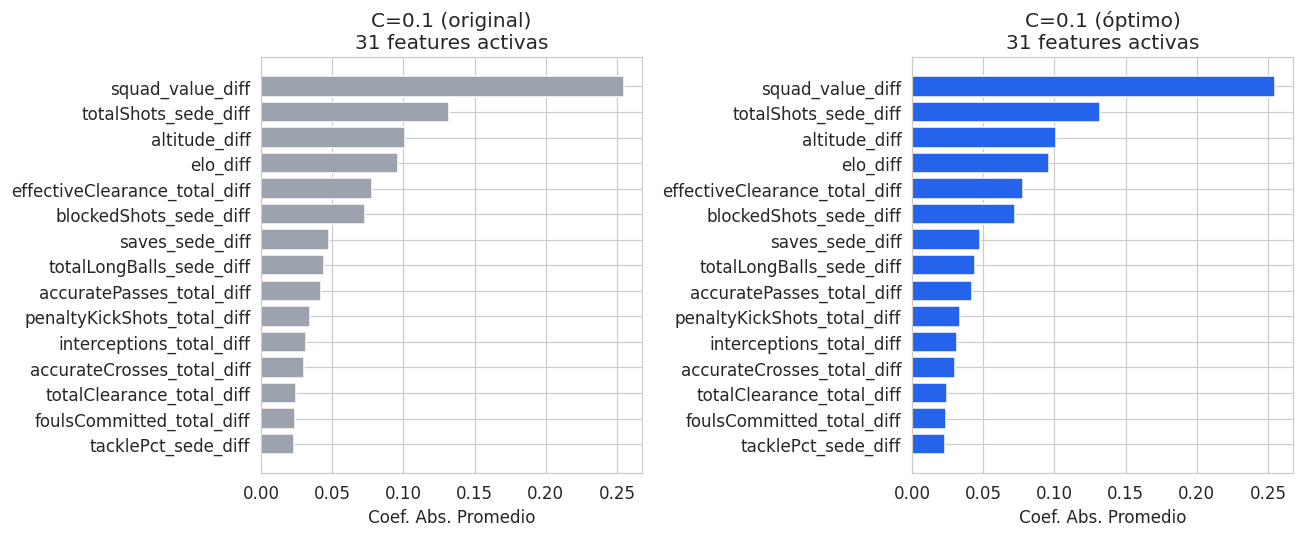

In [31]:
# Comparación de features activas: C original vs óptimo


> **Resultado:** El valor óptimo de C es **0.1**. El Log-Loss mejoró de **0.9907** a **0.9907** — una reducción del **0.0%**. Con C=0.1 el modelo usa **31 features** activas (vs 31 con C=0.1).

---
## 14. Calibración Post-Hoc de Probabilidades

### ¿Por qué calibrar?
Un modelo puede acertar el resultado (alta accuracy) pero tener probabilidades **sistemáticamente sesgadas**:
- Si dice '70% local' y en realidad gana el 55%, las cuotas de apuesta calculadas serán incorrectas.
- La calibración **corrige este sesgo** sin reentrenar el modelo desde cero.

### Métodos:
| Método | Descripción | Cuándo usarlo |
|---|---|---|
| **Platt Scaling** | Ajusta una regresión logística sobre las probabilidades crudas | Cuando la curva de calibración tiene forma sigmoidal |
| **Isotonic Regression** | Ajusta una función monotónica no paramétrica | Cuando hay suficientes datos (>1000) y la deformación no es sigmoidal |

Ambos métodos se aplican con `CalibratedClassifierCV` de scikit-learn, usando **TimeSeriesSplit** internamente para evitar data leakage.

In [32]:
from sklearn.calibration import CalibratedClassifierCV, calibration_curve

lr_base = LogisticRegression(penalty='l1', solver='liblinear', multi_class='ovr', C=0.1, max_iter=2000, random_state=42)

cal_platt    = CalibratedClassifierCV(lr_base, method='sigmoid',  cv=TimeSeriesSplit(n_splits=3))
cal_isotonic = CalibratedClassifierCV(lr_base, method='isotonic', cv=TimeSeriesSplit(n_splits=3))

lr_base.fit(Xtr_sc, y_train)
cal_platt.fit(Xtr_sc, y_train)
cal_isotonic.fit(Xtr_sc, y_train)

from sklearn.preprocessing import label_binarize
from sklearn.metrics import brier_score_loss

models_cal = {
    f'LR L1 (C=0.1, sin calibrar)': lr_base,
    '+ Platt Scaling (sigmoid)':         cal_platt,
    '+ Isotonic Regression':             cal_isotonic,
}}

for name, mdl in models_cal.items():
    p_ = mdl.predict_proba(Xte_sc)
    ll  = log_loss(y_test, p_, labels=[0,1,2])
    acc = accuracy_score(y_test, mdl.predict(Xte_sc))
    yb  = label_binarize(y_test, classes=[0,1,2])
    brier = np.mean([brier_score_loss(yb[:,i], p_[:,i]) for i in range(3)])
    print(f'  {name}: Log-Loss={ll:.4f} | Acc={acc:.2%} | Brier={brier:.4f}')

  LR L1 (C=0.1, sin calibrar): Log-Loss=0.9907 | Acc=52.34% | Brier=0.1972
  + Platt Scaling (sigmoid): Log-Loss=0.9936 | Acc=54.30% | Brier=0.1978
  + Isotonic Regression: Log-Loss=1.0674 | Acc=54.30% | Brier=0.1989


### Reliability Diagrams — Las 3 Clases × 3 Métodos

Cada gráfico muestra si las probabilidades predichas coinciden con las frecuencias reales. La **línea diagonal** = calibración perfecta.

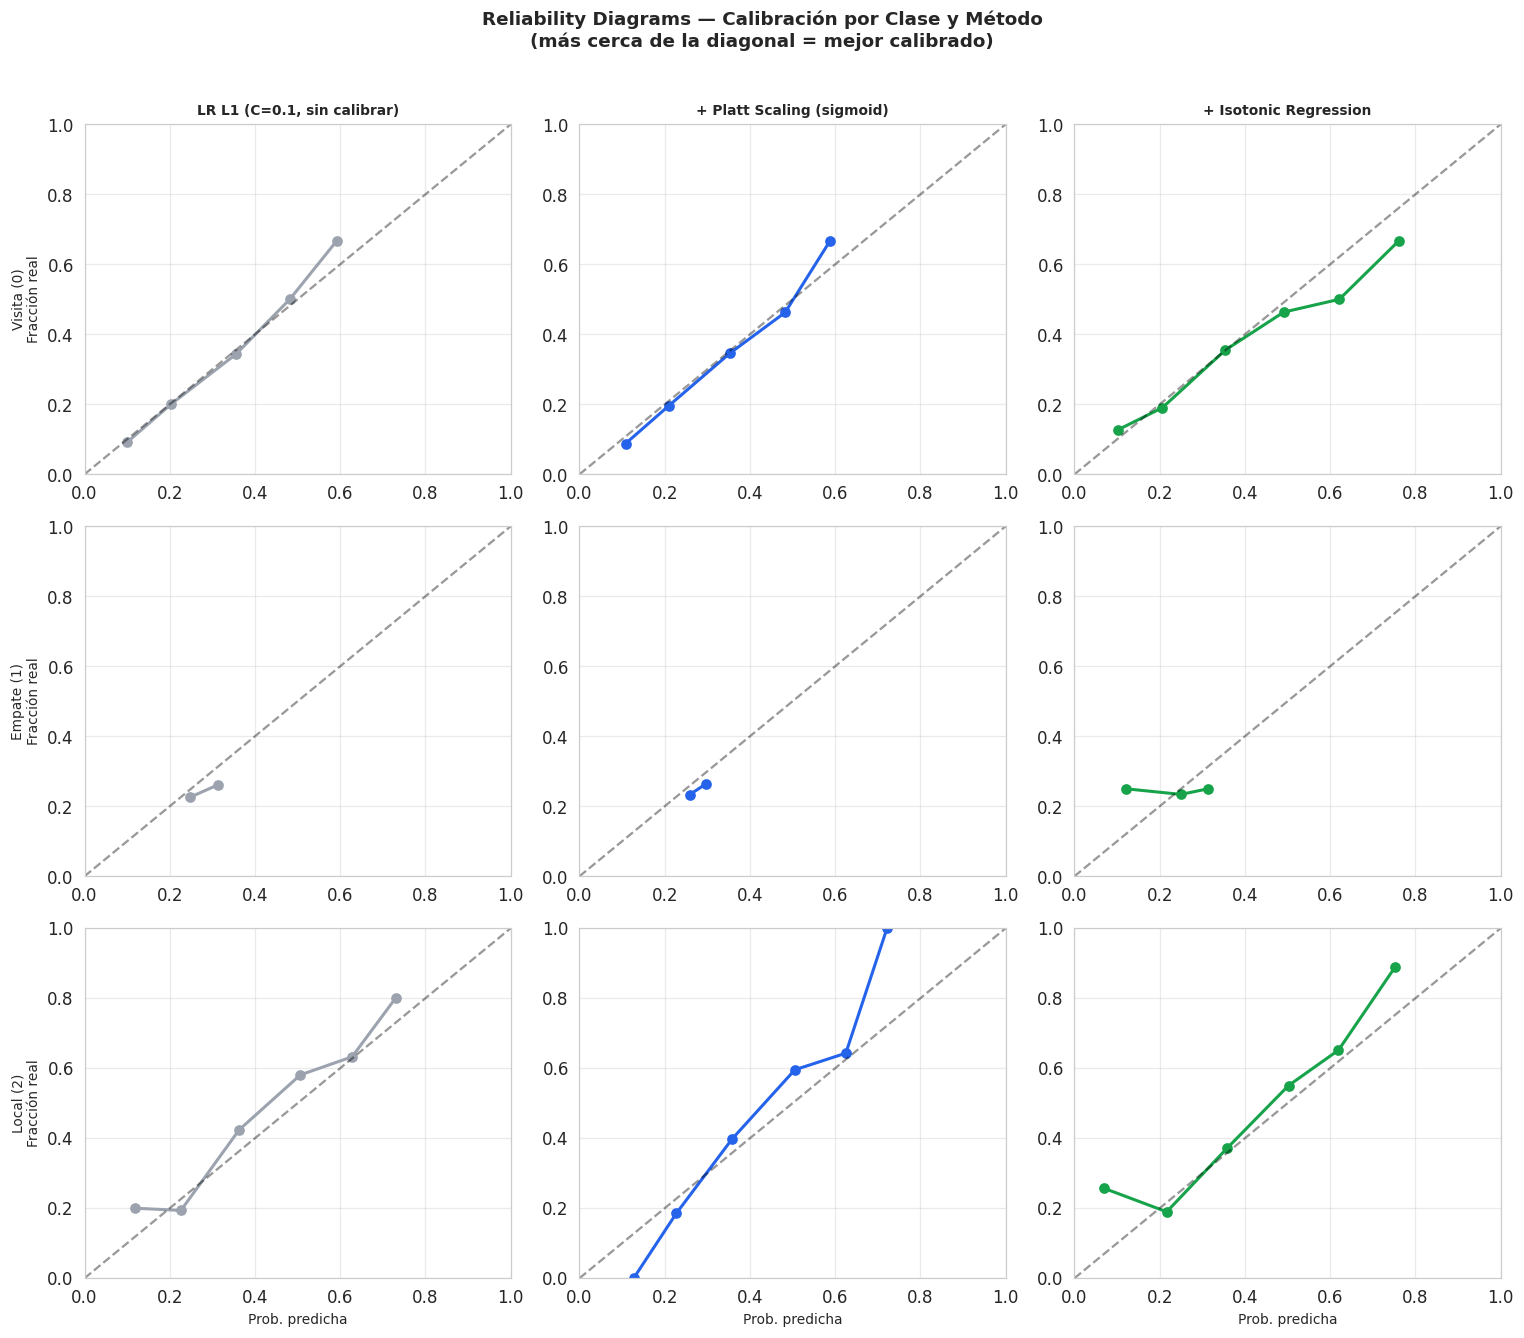

In [33]:
# Ver reliability diagrams


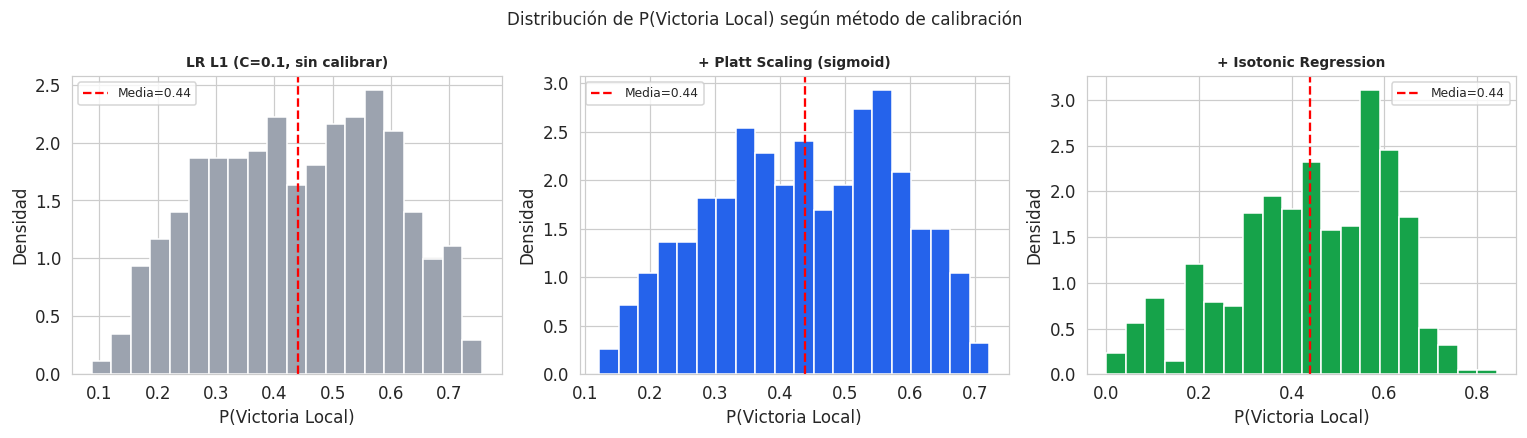

In [34]:
# Distribución de P(Victoria Local) por método


### Conclusión de Calibración

| Aspecto | Sin calibrar | Platt Scaling | Isotonic |
|---|---|---|---|
| Log-Loss | 0.9907 | 0.9936 | 1.0674 |
| Brier Score | 0.1972 | 0.1978 | 0.1989 |

> **Modelo final recomendado:** LR L1 con C=0.1 + **LR L1 (C=0.1, sin calibrar)**
> Este es el modelo a usar en producción para calcular cuotas y probabilidades del simulador Monte Carlo.